In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import joblib
import json
import os

In [2]:
from dotenv import load_dotenv
load_dotenv()

True

# Setup LLM

In [3]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0
)

# About Dataset

## Context
"Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs." [IBM Sample Data Sets]

## Content
Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

## The data set includes information about:

Customers who left within the last month – the column is called Churn
Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
Demographic info about customers – gender, age range, and if they have partners and dependents


In [4]:
df = pd.read_csv("../data/Telco-Customer-Churn.csv")

# EDA

In [5]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
df.shape

(7043, 21)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"],errors="coerce") # errors="coerce" -> transforme en Nan une valeur pas convertible

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df=df.dropna()

In [11]:
df["TotalCharges"].isna().sum()

np.int64(0)

In [12]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [13]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
df.drop("customerID",axis=1,inplace=True)

In [15]:
# target
df["Churn"]=df["Churn"].map({"Yes":1,"No":0})

In [16]:
df["Churn"].head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [17]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## Encoding

In [18]:
#df = pd.get_dummies(df, drop_first=True)

In [19]:
#df.head()

In [20]:
#df=df.astype(int)

In [21]:
#df.head()

In [22]:
df.shape

(7032, 20)

# Independent and dependent variables 

In [23]:
X=df.drop("Churn",axis=1)
y=df["Churn"]

# Split the data

In [24]:
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42,test_size=0.2)

In [25]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5625, 19)
(1407, 19)
(5625,)
(1407,)


# Features definition

In [26]:
X_train.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')

In [27]:
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]

categorical_features = [
    "gender", "Partner", "Dependents", "PhoneService", "MultipleLines",
    "InternetService", "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies", "Contract",
    "PaperlessBilling", "PaymentMethod"
]

In [28]:
preprocessor=ColumnTransformer(
    transformers=[
        ("num",StandardScaler(),numeric_features),
        ('cat',OneHotEncoder(handle_unknown="ignore"),categorical_features)
    ]
)

# Scale the data

In [29]:
#scaler=StandardScaler()
#X_train_scaled=scaler.fit_transform(X_train)
#X_test_scaled=scaler.transform(X_test)

In [30]:
#pd.DataFrame(X_train_scaled)

# Models

## XgBoost Classifier/GradientBoostingClassifier/AdaBoost Classifier/Random Forest Classifier / Decision Tree Classifier / Logistic Regression

In [31]:
models= {
    "XgBoost":XGBClassifier(),
    "GradientBoosting":GradientBoostingClassifier(),
    "AdaBoost":AdaBoostClassifier(),
    "DecisionTree":DecisionTreeClassifier(class_weight="balanced"),
    "RandomForest":RandomForestClassifier(class_weight="balanced"),
    "LogisticRegression":LogisticRegression(class_weight="balanced")
}

for name, model in models.items():

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)

    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    y_train_proba = pipe.predict_proba(X_train)[:, 1]
    y_test_proba = pipe.predict_proba(X_test)[:, 1]

    # Metrics

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred)
    model_train_precision = precision_score(y_train, y_train_pred)
    model_train_recall = recall_score(y_train, y_train_pred)
    model_train_f1_score = f1_score(y_train, y_train_pred, average='weighted')
    model_train_roc_auc_score = roc_auc_score(y_train, y_train_proba)

    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_precision = precision_score(y_test, y_test_pred)
    model_test_recall = recall_score(y_test, y_test_pred)
    model_test_f1_score = f1_score(y_test, y_test_pred, average='weighted')
    model_test_roc_auc_score = roc_auc_score(y_test, y_test_proba)

    print("----------------------------------------")
    print(name)

    print("Model performance for training set")
    print("Accuracy :", model_train_accuracy)
    print("Precision :", model_train_precision)
    print("Recall :", model_train_recall)
    print("F1 score :", model_train_f1_score)
    print("ROC AUC :", model_train_roc_auc_score)

    print("Model performance for test set")
    print("Accuracy :", model_test_accuracy)
    print("Precision :", model_test_precision)
    print("Recall :", model_test_recall)
    print("F1 score :", model_test_f1_score)
    print("ROC AUC :", model_test_roc_auc_score)

----------------------------------------
XgBoost
Model performance for training set
Accuracy : 0.9409777777777778
Precision : 0.9013112491373361
Recall : 0.8735785953177257
F1 score : 0.9406801040746983
ROC AUC : 0.9866159190846
Model performance for test set
Accuracy : 0.7604832977967306
Precision : 0.5587301587301587
Recall : 0.47058823529411764
F1 score : 0.7535532839394883
ROC AUC : 0.8075241625295723
----------------------------------------
GradientBoosting
Model performance for training set
Accuracy : 0.8293333333333334
Precision : 0.720164609053498
Recall : 0.5852842809364549
F1 score : 0.8233144193737019
ROC AUC : 0.8833299861523884
Model performance for test set
Accuracy : 0.7938877043354655
Precision : 0.6468531468531469
Recall : 0.4946524064171123
F1 score : 0.7843571636445705
ROC AUC : 0.8357763328864063
----------------------------------------
AdaBoost
Model performance for training set
Accuracy : 0.8072888888888888
Precision : 0.6685808039376538
Recall : 0.545150501672240

J’ai comparé plusieurs modèles. Même si certains avaient une meilleure accuracy, j’ai privilégié un modèle avec un recall élevé sur la classe churn. J’ai donc retenu une logistic regression avec class_weight balanced, qui détecte près de 80% des churners.

In [32]:
# Avec Pipeline, on doit préfixer "model__"
params = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs"]
}

In [33]:
pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000))
])


grid = GridSearchCV(
    pipe,
    param_grid=params,
    scoring="recall",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_grid,"{'model__C': [0.01, 0.1, ...], 'model__penalty': ['l2'], 'model__solver': ['lbfgs']}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [34]:
print(grid.best_params_)

{'model__C': 10, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}


In [35]:
print(grid.best_score_)

0.7959866220735785


Le modèle détecte environ 80% des churners

In [36]:
best_model = grid.best_estimator_

In [37]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

In [38]:

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1033
           1       0.50      0.79      0.62       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407



Le modèle atteint un recall de 79% sur les churners, ce qui permet de détecter efficacement les clients à risque. J’ai volontairement accepté une baisse de précision afin de maximiser la détection, ce qui est cohérent dans un contexte business.

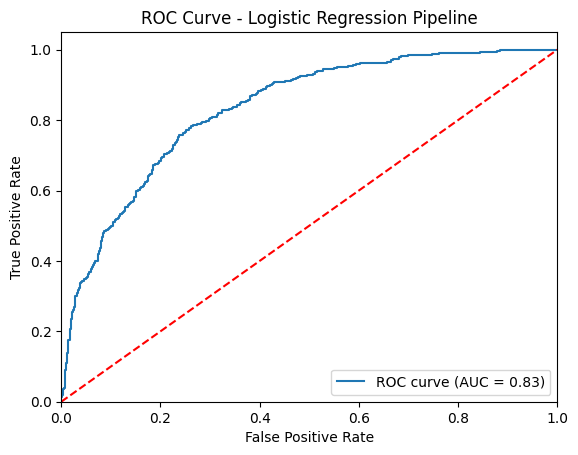

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure()

y_proba = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

auc_score = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc_score:.2f})")

plt.plot([0,1],[0,1],'r--')
plt.xlim([0.0,1.0])
plt.ylim([0.0, 1.05])

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend(loc="lower right")
plt.title("ROC Curve - Logistic Regression Pipeline")

plt.show()

# Save

In [40]:
joblib.dump(best_model, "../models/model.pkl")

['../models/model.pkl']

# Load

In [41]:
import joblib

model = joblib.load("../models/model.pkl")

 model.pkl contient :

- preprocessing 
- encoding 
- scaling 
- modèle 

# Agent

## Functions

In [42]:
# Tool prediction

def predict_churn(input_data):

    df = pd.DataFrame([input_data])

    # conversions sécurisées
    if "MonthlyCharges" in df.columns:
        df["MonthlyCharges"] = df["MonthlyCharges"].astype(float)

    if "TotalCharges" in df.columns:
        df["TotalCharges"] = df["TotalCharges"].astype(float)

    if "tenure" in df.columns:
        df["tenure"] = df["tenure"].astype(int)

    proba = model.predict_proba(df)[0][1]

    return float(proba)

# Tool simulation

def simulate_change(input_data, feature, new_value):

    input_copy = input_data.copy()

    input_copy[feature] = new_value

    df = pd.DataFrame([input_copy])

    # conversions sécurisées
    if "MonthlyCharges" in df.columns:
        df["MonthlyCharges"] = df["MonthlyCharges"].astype(float)

    if "TotalCharges" in df.columns:
        df["TotalCharges"] = df["TotalCharges"].astype(float)

    if "tenure" in df.columns:
        df["tenure"] = df["tenure"].astype(int)

    proba = model.predict_proba(df)[0][1]

    return float(proba)


# Tool recommandation

def agent_recommendation(input_data):
    
    churn = predict_churn(input_data)
    
    context = []
    insights = []
    recommendations = []
    
     # CONTEXT 
    if input_data.get("SeniorCitizen") == 1:
        context.append("Senior customer → may require more support")
    
    if input_data.get("Partner") == "No":
        context.append("No partner → potentially lower engagement")
    
    if input_data.get("Dependents") == "No":
        context.append("No dependents → lower switching cost")
    
    if input_data.get("gender") == "Female":
        context.append("Segment may require tailored engagement")

    # ANALYSE 
    
    # Engagement
    if input_data.get("tenure", 0) < 12:
        insights.append("Low tenure")
        recommendations.append("Implement onboarding and loyalty program")
    
    if input_data.get("Contract") == "Month-to-month":
        insights.append("Short-term contract")
        recommendations.append("Offer long-term contract")
    
    # Services
    if input_data.get("TechSupport") == "No":
        insights.append("No technical support")
        recommendations.append("Promote technical support services")
    
    if input_data.get("OnlineSecurity") == "No":
        recommendations.append("Offer security add-on")
    
    if input_data.get("OnlineBackup") == "No":
        recommendations.append("Offer backup service")
    
    if input_data.get("DeviceProtection") == "No":
        recommendations.append("Promote device protection plan")
    
    # Internet
    if input_data.get("InternetService") == "Fiber optic":
        insights.append("Fiber optic users tend to churn more")
        recommendations.append("Improve perceived value or support")
    
    # Pricing
    if input_data.get("MonthlyCharges", 0) > 80:
        insights.append("High monthly charges")
        recommendations.append("Propose discount or bundle")
    
    # Payment
    if input_data.get("PaymentMethod") == "Electronic check":
        insights.append("Risky payment method")
        recommendations.append("Encourage automatic payment")
    
    # Experience
    if input_data.get("StreamingTV") == "No" and input_data.get("StreamingMovies") == "No":
        insights.append("Low entertainment engagement")
        recommendations.append("Promote entertainment bundle")
    
    # Phone usage
    if input_data.get("MultipleLines") == "No":
        recommendations.append("Upsell multiple lines")
    
    if input_data.get("PhoneService") == "No":
        recommendations.append("Offer phone service bundle")
    
    # Billing
    if input_data.get("PaperlessBilling") == "Yes":
        recommendations.append("Ensure billing transparency and clarity")
    
    
    # PRIORISATION (même actions, niveau d'urgence différent)
    
    if churn > 0.7:
        risk_level = "High churn risk"
        recommendations = [f"URGENT: {rec}" for rec in recommendations]
    
    elif churn > 0.4:
        risk_level = "Medium churn risk"
    
    else:
        risk_level = "Low churn risk"
        recommendations = ["Maintain engagement and monitor customer satisfaction"]
    
    
    return {
        "churn_probability": float(round(churn, 3)),
        "risk_level": risk_level,
        "context": context[:3],
        "key_insights": insights[:5],
        "recommendations": recommendations[:5]
    }

## Client schema

In [43]:
from pydantic import BaseModel
from typing import Literal


class CustomerInput(BaseModel):

    gender: str
    SeniorCitizen: int
    Partner: str
    Dependents: str
    tenure: int
    PhoneService: str
    MultipleLines: str
    InternetService: str
    OnlineSecurity: str
    OnlineBackup: str
    DeviceProtection: str
    TechSupport: str
    StreamingTV: str
    StreamingMovies: str
    Contract: str
    PaperlessBilling: str
    PaymentMethod: str
    MonthlyCharges: float
    TotalCharges: float

In [44]:
class SimulationInput(CustomerInput):

    feature: str
    new_value: str

## Tools definition

In [45]:
from typing import Any,Dict

def predict_churn_tool(input_data: CustomerInput):

    result = predict_churn(input_data.model_dump())

    return f"Churn probability: {round(result, 3)}"


def recommendation_tool(input_data: CustomerInput):

    result = agent_recommendation(input_data.model_dump())

    return result


def simulate_change_tool(data: SimulationInput):

    customer_data = data.model_dump()

    feature = customer_data.pop("feature")
    new_value = customer_data.pop("new_value")

    old_proba = predict_churn(customer_data)

    new_proba = simulate_change(
        customer_data,
        feature,
        new_value
    )

    delta = new_proba - old_proba

    if delta < 0:
        impact = "reduced churn risk"
    elif delta > 0:
        impact = "increased churn risk"
    else:
        impact = "no impact"

    return {
        "old_probability": round(old_proba, 3),
        "new_probability": round(new_proba, 3),
        "delta": round(delta, 3),
        "impact": impact
    }

In [46]:
from langchain_core.tools import StructuredTool

predict_tool = StructuredTool.from_function(
    func=predict_churn_tool,
    name="predict_churn",
    description="Predict customer churn probability."
)

recommend_tool = StructuredTool.from_function(
    func=recommendation_tool,
    name="recommend_action",
    description="Generate customer retention recommendations."
)

simulate_tool = StructuredTool.from_function(
    func=simulate_change_tool,
    name="simulate_change",
    description="Simulate impact of changing customer features."
)

tools = [
    predict_tool,
    recommend_tool,
    simulate_tool
]

StructuredTool fait automatiquement :

- parsing des arguments 
- validation 
- conversion 

## Creating agent

In [47]:
from langchain.agents import create_agent

agent = create_agent(
    llm,
    tools=tools,
    system_prompt="""
You are a customer churn analysis agent.

Your responsibilities:
- Analyze customer profiles
- Predict churn probability
- Provide business recommendations
- Prioritize actions based on expected impact

Rules:
- Always use predict_churn first
- Use recommend_action to generate recommendations
- Use simulate_change to validate important actions
- Be concise, professional, and data-driven
- Rank recommendations by expected impact on churn reduction

Important:
- Simulation results are based on statistical patterns, not causal relationships
- If a result seems counterintuitive, explain that the model may reflect correlations in the dataset
- Do not blindly trust simulation results

When a simulation result is ineffective or counterintuitive:
- Explicitly state that the action is not recommended
- Suggest alternative actions
- Focus on the most impactful drivers such as contract type, tenure, support services, and customer engagement
- Never mention internal tool errors to the user
- If a simulation fails, continue the analysis gracefully
"""
)

## Calling Agent

In [48]:
input_data = {
    "gender": "Male",
    "SeniorCitizen": 0,
    "Partner": "No",
    "Dependents": "No",
    "tenure": 2,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "No",
    "OnlineBackup": "No",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 90,
    "TotalCharges": 180
}

In [49]:
result = agent.invoke({
    "messages":[
        {
            "role":"user",
            "content": f"Analyse this customer: {input_data}"
        }
    ]
})

In [50]:
print(result["messages"][-1].content)

### Customer Churn Analysis

**Churn Probability:** 66.9% (Medium churn risk)

**Key Insights:**
- Low tenure (2 months)
- Month-to-month contract
- No technical support
- Fiber optic users tend to churn more
- High monthly charges ($90)

### Recommendations to Reduce Churn

1. **Implement Onboarding and Loyalty Program**
   - **Expected Impact:** High
   - Engaging customers early can increase retention.

2. **Offer Long-term Contract (e.g., One Year)**
   - **Expected Impact:** High
   - Simulation shows a reduction in churn probability from 66.9% to 47% (19.9% improvement).

3. **Promote Technical Support Services**
   - **Expected Impact:** Medium
   - Simulation shows a slight reduction in churn probability from 66.9% to 63.9% (3% improvement).

4. **Offer Security Add-on**
   - **Expected Impact:** Medium
   - Simulation shows a slight reduction in churn probability from 66.9% to 63.3% (3.5% improvement).

5. **Offer Backup Service**
   - **Expected Impact:** Medium
   - This can